In [31]:
from alerce.core import Alerce
import pandas as pd
from astropy.table import vstack, Table
import matplotlib.pyplot as plt
import pyvo as vo
import requests
import sqlalchemy as sa
import sys
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
import re
import george
import scipy.optimize as op
import emcee
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier

In [32]:
#load in data
sn1a1 = Table.read("../Data/SNIa_fits1.ecsv")
sn1a2 = Table.read("../Data/SNIa_fits2.ecsv")
snII = Table.read("../Data/SNII_fits.ecsv")
snIb = Table.read("../Data/SNIb_fits.ecsv")
snIc = Table.read("../Data/SNIc_fits.ecsv")

In [33]:
#combine data
rises = []
falls = []
peaks = []
label = []
SNe = [sn1a1, sn1a2, snII, snIb, snIc]
encoder = np.array(["SNIa", "SNII", "SNIb", "SNIc"])

for sn in SNe:
    for stype, peak, rise, fall in zip(sn["type"], sn["peak"], sn["rise"], sn["fall"]):
        l = np.where(encoder == stype)[0]
        rises.append(rise)
        falls.append(fall)
        peaks.append(peak)
        label.append(l)

rises = np.array(rises)
falls = np.array(falls)
peaks = np.array(peaks)

In [34]:
#normalize data
rises_n = rises / np.max(rises)
falls_n = falls / np.max(falls)
peaks_n = peaks / np.max(peaks)
print(np.min(rises_n))

0.0


In [35]:
#build feature space
features = Table([rises_n, peaks_n, falls_n], names=["Rise", "Peak", "Fall"]) # add falls back

In [36]:
#resample
resampler = SMOTE(sampling_strategy="auto", k_neighbors=3)


features_resampled, labels_resampled = resampler.fit_resample(features.to_pandas(), label)

In [44]:
# #initializing primary components
# pca = PCA(n_components=2)

# #training pca
# pca.fit(features_resampled)
# #print(len(wine.data))

# #reducing data
# features_pca = pca.transform(features_resampled)
# #print(wine_pca)

# #making data frame
# features_pca_df = pd.DataFrame(features_pca)

In [45]:
#initialize ml
#clf = RandomForestClassifier(max_depth=None, random_state=0)
clf = KNeighborsClassifier(n_neighbors=10)

#use ml with cross validation
predict_clf = cross_val_predict(clf, features_resampled, labels_resampled)

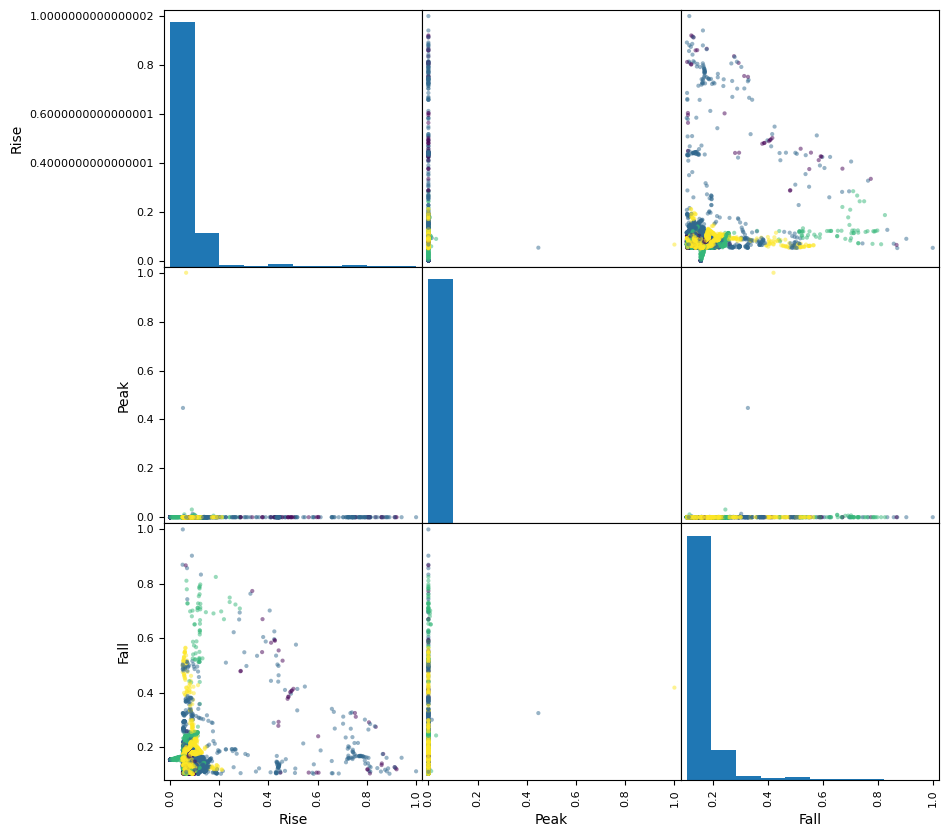

In [46]:
pd.plotting.scatter_matrix(features_resampled, figsize=(10,10), c=predict_clf, cmap="viridis");

In [47]:
print(f"Accuracy: {np.sum(np.logical_and(predict_clf, labels_resampled))/len(labels_resampled)}")

Accuracy: 0.6825714285714286


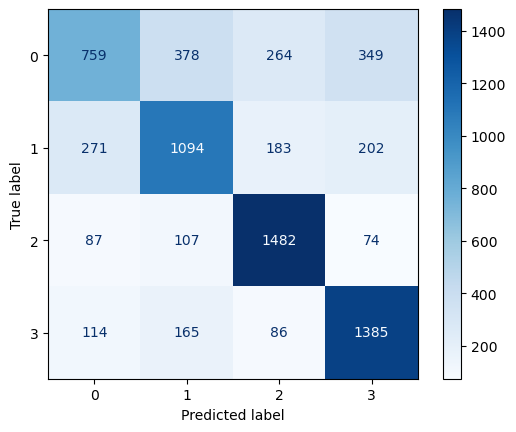

In [48]:
confusion_matrix = metrics.cluster.contingency_matrix(labels_resampled, predict_clf)

disp = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

Text(0.5, 0.98, 'Normalized by Row')

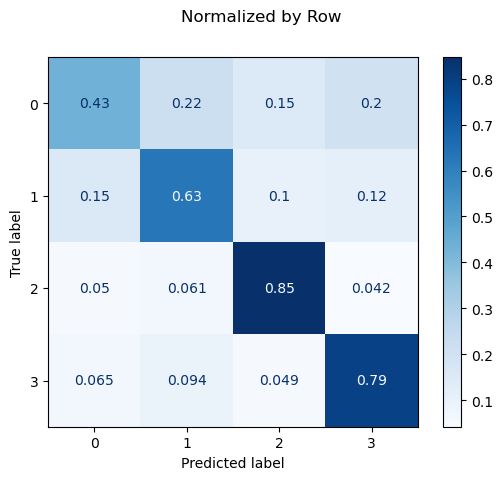

In [49]:
confusion_matrix_row = metrics.confusion_matrix(labels_resampled, predict_clf, normalize="true")
disp2 = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_row)
disp2.plot(cmap=plt.cm.Blues)
plt.suptitle("Normalized by Row")

Text(0.5, 0.98, 'Normalized by Col')

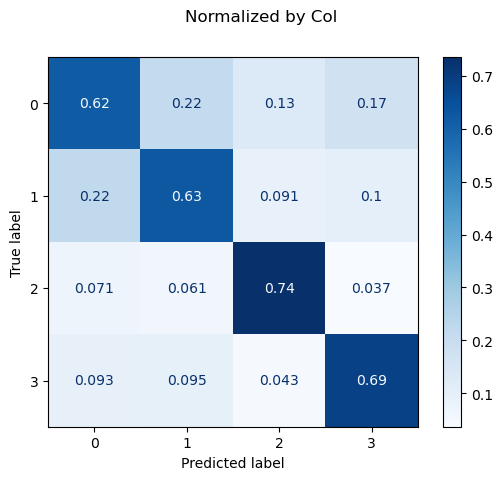

In [50]:
confusion_matrix_row = metrics.confusion_matrix(labels_resampled, predict_clf, normalize="pred")
disp2 = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_row)
disp2.plot(cmap=plt.cm.Blues)
plt.suptitle("Normalized by Col")